# Transformer for Jet Classification

Tinkering + Extra modifications

In [2]:
import h5py
import numpy as np
from numpy.lib.recfunctions import structured_to_unstructured

In [3]:
import torch
print(torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

True
Using cuda device


In [4]:
import os
import urllib.request
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

filename = "/content/drive/MyDrive/part_transformer.h5"
url = "https://cernbox.cern.ch/s/4rtGlo1RlFvUNwz/download/"

if not os.path.exists(filename):
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")
else:
    print(f"{filename} already exists. Skipping download.")

Mounted at /content/drive
/content/drive/MyDrive/part_transformer.h5 already exists. Skipping download.


In [5]:
with h5py.File(filename,"r") as f:
  signal_data = f["signal"][:]
  bkg_data = f["bkg"][:]

In [6]:
signal = structured_to_unstructured(signal_data)
background = structured_to_unstructured(bkg_data)

In [7]:
X = np.concatenate([signal,background])
X.shape #Already in the transformer shape we need i.e. Ndata x Ntokens x Nfeatures

(873126, 20, 5)

In [8]:
target = np.concatenate([np.ones(signal.shape[0]), np.zeros(background.shape[0])], axis=0)


In [9]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
X_train, X_temp, Y_train, Y_temp = train_test_split(X, target, test_size=0.2, random_state=42)

# Second split: 10% validation, 10% test
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Train: 698500 samples
Validation: 87313 samples
Test: 87313 samples


In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, 5))  # 5 features per jet

X_train_scaled = scaler.transform(X_train.reshape(-1, 5)).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val.reshape(-1, 5)).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 5)).reshape(X_test.shape)

In [99]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32, device=device)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)

Y_train_tensor = torch.tensor(Y_train.reshape(-1, 1), dtype=torch.float32, device=device)
Y_val_tensor = torch.tensor(Y_val.reshape(-1, 1), dtype=torch.float32, device=device)
Y_test_tensor = torch.tensor(Y_test.reshape(-1, 1), dtype=torch.float32, device=device)

In [120]:
import torch.nn as nn
import torch.nn.functional as F

dropout_rate = 0.010

class JetTransformer(nn.Module):

    """
    Transformer model for jet classification
    First step is an embedder for particles
    Next step is a set of transformer encoder layers
    Last step is a classifier head
    """

    def __init__(self, input_dim, nhead, num_layers, dropout_rate):
        super(JetTransformer, self).__init__()

        # Input embedding MLP components
        self.linear1_embed = nn.Linear(input_dim, 64)
        self.relu1_embed = nn.ReLU()
        self.linear2_embed = nn.Linear(64, 64) # Changed from 32 to 64
        self.relu2_embed = nn.ReLU()

        # Transformer Encoder - made of TransformerEncoderLayers
        # Note: TransformerEncoderLayer has LayerNorm and Dropout built-in
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=64, nhead=nhead, batch_first=True, dropout=dropout_rate),
            num_layers=num_layers, enable_nested_tensor=False)

        # Output classifier MLP
        self.output_classifier_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 1))

    def mean_pooling(self,x):
        """
        Mean pooling implementation
        """
        # x: (batch_size, num_tokens, embed_dim)
        return x.mean(dim=1)


    def forward(self, x):
        # Input to embedder: (batch_size, num_tokens, input_dim)
        # First embedding block
        x = self.linear1_embed(x) # Output: (batch_size, num_tokens, 16)
        x = self.relu1_embed(x)
        # Second embedding block
        x = self.linear2_embed(x) # Output: (batch_size, num_tokens, 32)
        x = self.relu2_embed(x)
        # Transformer part
        x = self.transformer_encoder(x)
        # Pooling layer
        x = self.mean_pooling(x) # Output: (batch_size, 32)

        # Classifier head
        x = self.output_classifier_head(x)
        return x

In [121]:
model = JetTransformer(input_dim=5, nhead=1, num_layers=1,dropout_rate=dropout_rate)
model = model.to(device)

In [122]:

from torch.utils.data import TensorDataset, DataLoader

batch_size = 8192

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [123]:
# Define optimiser and loss function
from torch.optim.lr_scheduler import LambdaLR
learning_rate = 0.1
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.BCEWithLogitsLoss()

# Define scheduler
warmup_steps = 86
def lr_lambda(current_step: int):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    return max(
        0.0, float(warmup_steps) / float(current_step)
    )


scheduler = LambdaLR(optimizer, lr_lambda)

In [124]:
import time

print("\nBeginning training loop")
print("=" * 60)

train_losses = []
val_losses = []
times = []

num_epochs = 10

for epoch in range(num_epochs):
    start_time = time.time()  # Start timer

    # --- Training ---
    model.train()
    running_train_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        scheduler.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    epoch_time = time.time() - start_time  # End timer
    times.append(epoch_time)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {epoch_time:.2f}s")

    torch.cuda.empty_cache()


Beginning training loop
Epoch 1/10 | Train Loss: 0.4990 | Val Loss: 0.5656 | Time: 29.25s
Epoch 2/10 | Train Loss: 0.5203 | Val Loss: 0.4015 | Time: 26.80s
Epoch 3/10 | Train Loss: 0.3567 | Val Loss: 0.3309 | Time: 28.02s
Epoch 4/10 | Train Loss: 0.3266 | Val Loss: 0.3215 | Time: 26.95s
Epoch 5/10 | Train Loss: 0.3197 | Val Loss: 0.3224 | Time: 26.52s
Epoch 6/10 | Train Loss: 0.3192 | Val Loss: 0.3170 | Time: 27.34s
Epoch 7/10 | Train Loss: 0.3159 | Val Loss: 0.3191 | Time: 26.55s
Epoch 8/10 | Train Loss: 0.3152 | Val Loss: 0.3167 | Time: 27.18s
Epoch 9/10 | Train Loss: 0.3137 | Val Loss: 0.3131 | Time: 26.82s
Epoch 10/10 | Train Loss: 0.3244 | Val Loss: 0.3255 | Time: 27.11s


In [125]:
# Evaluate by looping over the test_dataset
model.eval()
list_of_predictions = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)  # if using GPU

        outputs = model(inputs)
        list_of_predictions.append(outputs)
        loss = criterion(outputs, targets)

Given accuracy =  0.8605476847663005
Confusion matrix =  [[44130  5784]
 [ 6392 31007]]
Normalized Confusion matrix =  [[0.88412069 0.11587931]
 [0.17091366 0.82908634]]
Precision score =  0.8603339539507548
Recall score =  0.8605476847663005
F1 score =  0.8603983614391971
Given ROC-AUC score = 0.8566035133947865


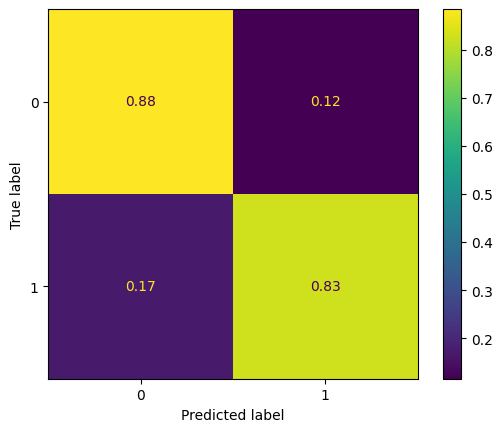

In [126]:
# Performance metrics

pred = torch.concatenate(list_of_predictions)
Y_pred = torch.round(torch.sigmoid(pred)).detach().cpu().numpy()
target = Y_test

# Accuracy scorer

from sklearn.metrics import accuracy_score # Import an accuracy scorer from SKLearn
accuracy = accuracy_score(target, Y_pred)
print("Given accuracy = ",accuracy)

# Confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Import a confusion matrix from SKLearn
conf_matrix = confusion_matrix(target, Y_pred)
print("Confusion matrix = ",conf_matrix)

# Normalized confusion matrix
norm_conf_matrix = confusion_matrix(target, Y_pred, normalize='true')
print("Normalized Confusion matrix = ",norm_conf_matrix)
display_matrix = ConfusionMatrixDisplay(confusion_matrix=norm_conf_matrix)
display_matrix.plot()

# Precision, recall, and f1 scores

from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(target, Y_pred, average='weighted')
print("Precision score = ",precision)
recall = recall_score(target, Y_pred, average='weighted')
print("Recall score = ",recall)
f1 = f1_score(target, Y_pred, average='weighted')
print("F1 score = ",f1)

# ROC-AUC Score

from sklearn.metrics import roc_auc_score
print(f"Given ROC-AUC score = {roc_auc_score(Y_test.reshape(-1,1),Y_pred)}")

plt.show()

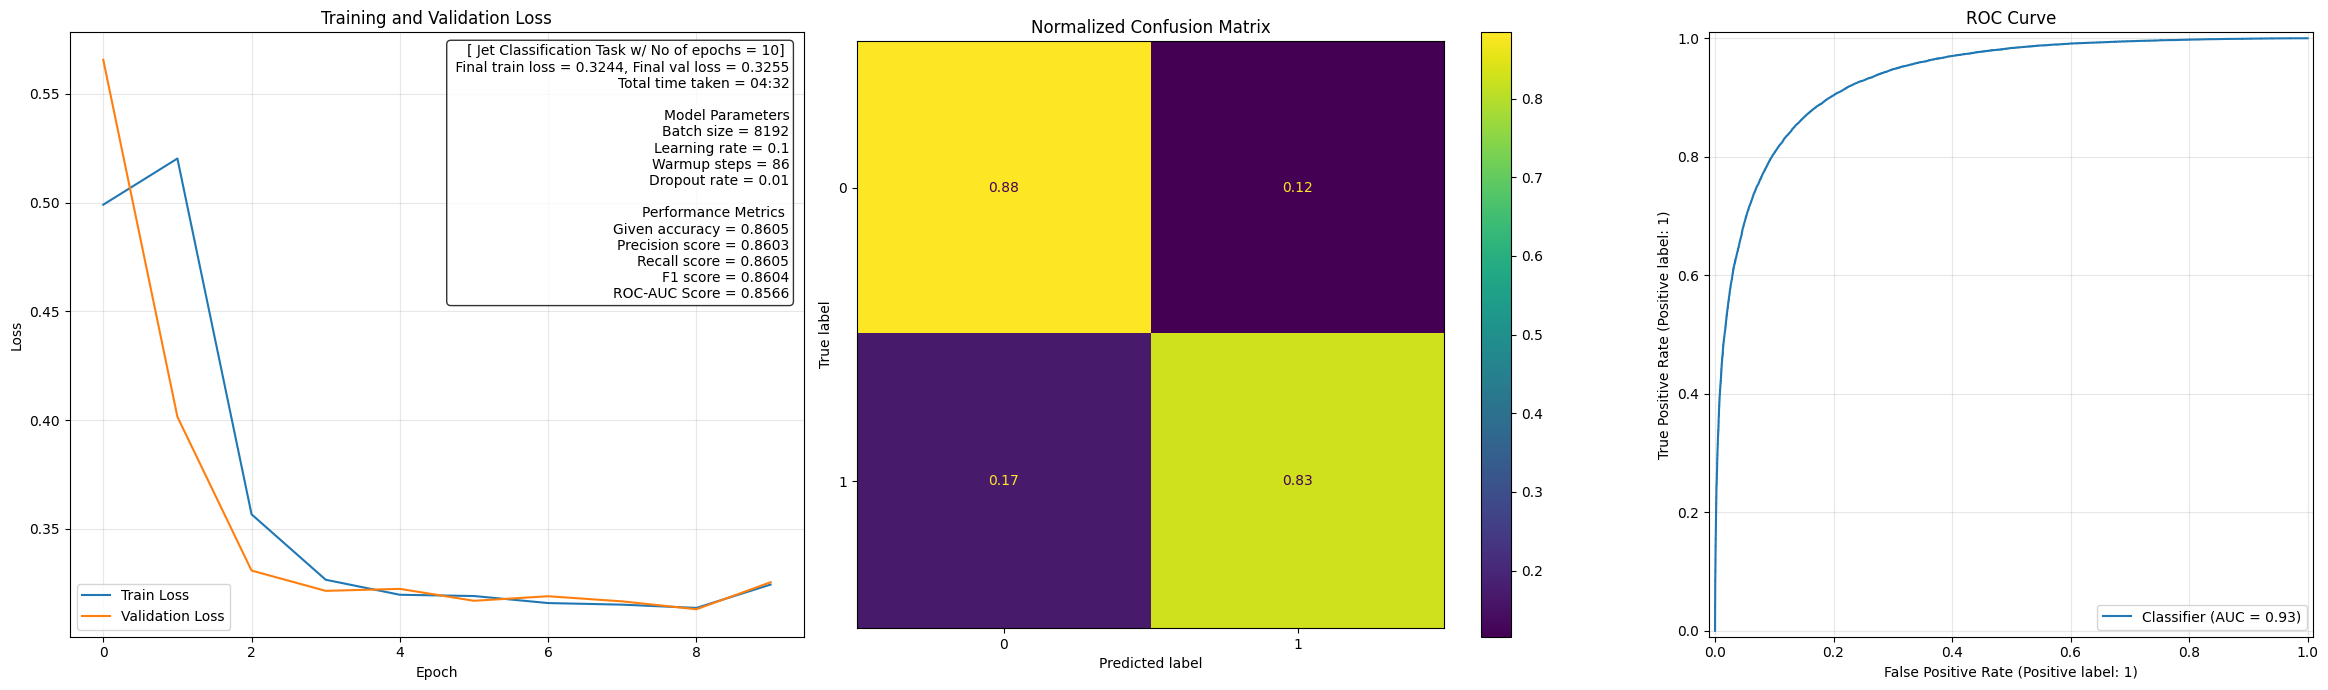

In [127]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# Adjust figsize to make room for three plots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot 1: Training and Validation Loss
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add the performance metrics as text to the first subplot
axes[0].text(
    0.98, 0.98, # Position in axes coordinates (top right)
    f"[ Jet Classification Task w/ No of epochs = {num_epochs}] \n Final train loss = {train_losses[-1]:.4f}, Final val loss = {val_losses[-1]:.4f}\nTotal time taken = {time.strftime("%M:%S", time.gmtime(sum(times)))}\n\nModel Parameters\nBatch size = {batch_size}\nLearning rate = {learning_rate}\nWarmup steps = {warmup_steps}\nDropout rate = {dropout_rate}\n\nPerformance Metrics \nGiven accuracy = {accuracy:.4f}\nPrecision score = {precision:.4f}\nRecall score = {recall:.4f}\nF1 score = {f1:.4f}\nROC-AUC Score = {roc_auc_score(Y_test.reshape(-1,1),Y_pred):.4f}",
    fontsize=10,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="black",
        alpha=0.8
    ),
    ha="right", # Right align
    va="top",   # Top align
    transform=axes[0].transAxes # Use axes coordinates
)

# Plot 2: Normalized Confusion Matrix
display_matrix = ConfusionMatrixDisplay(confusion_matrix=norm_conf_matrix, display_labels=[0, 1]) # Assuming labels are 0 and 1
display_matrix.plot(ax=axes[1], cmap='viridis') # Plot on the second axes
axes[1].set_title('Normalized Confusion Matrix')

# Plot 3: ROC-AUC Curve
# Need the raw probabilities for ROC curve, not rounded predictions
# Assuming 'pred' contains the raw logits before sigmoid and rounding
probabilities = torch.sigmoid(pred).detach().cpu().numpy()

roc_display = RocCurveDisplay.from_predictions(Y_test.reshape(-1,1), probabilities, ax=axes[2])
axes[2].set_title('ROC Curve')
axes[2].grid(True, alpha=0.3)

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()